# Домашнее задание "Корреляционный и регрессионный анализ"

**Инструкции:**
- Скачайте файл `practical_module_dataset.csv` и заполните ячейки с заданиями кодом и выводами.
- В каждой задаче требуется:
  - короткая формулировка метода и обоснование,
  - код/расчёты,
  - результаты (коэффициенты, статистики, p-value, CI, R²),
  - промежуточный вывод.
- Используйте `numpy`, `pandas`, `scipy`, `statsmodels` или `scikit-learn` по желанию. При необходимости предобработки данных (очистка, удаление пропусков) укажите свои действия.
- Для воспроизводимости задан `np.random.seed` - не меняйте его!

**Формат сдачи:** `.ipynb` с заполненными ячейками, кодом и выводами.

In [140]:
# ячейка с импортами - дополняйте по своему желанию!
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(28)

In [141]:
df = pd.read_csv('practical_module_dataset.csv')
df.shape
df.head()

,id,age,height_cm,weight_kg,iq,tv_hours,study_hours,score
0,1,24,155.2,51.37,91,11,11.9,76.5
1,2,37,184.9,76.49,90,15,4.0,65.4
2,3,32,169.8,64.24,98,6,10.6,78.2
3,4,28,173.6,68.22,88,9,9.2,75.6
4,5,25,174.2,73.80,102,8,8.0,75.1


### Задание 1.
Выполните первичный анализ данных (EDA):
1. посмотрите на `describe()` для всех переменных,
2. проверьте наличие пропусков и типы данных через `info()`,
3. запишите наблюдения в текстовой ячейке.

In [142]:
df.describe()

,id,age,height_cm,weight_kg,iq,tv_hours,study_hours,score
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,29.400000,169.153333,62.734000,100.433333,12.266667,7.640000,73.400000
std,8.803408,6.672641,9.584101,9.201488,12.119188,3.832109,3.281568,8.253693
min,1.000000,18.000000,148.200000,44.750000,82.000000,6.000000,2.700000,58.900000
25%,8.250000,24.250000,163.250000,56.622500,91.000000,9.000000,4.975000,67.800000
50%,15.500000,29.000000,169.750000,63.675000,97.000000,12.000000,7.650000,74.300000
75%,22.750000,35.500000,174.100000,68.602500,109.750000,14.000000,9.450000,78.725000
max,30.000000,39.000000,185.800000,81.130000,132.000000,22.000000,14.400000,91.500000


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           30 non-null     int64  
 1   age          30 non-null     int64  
 2   height_cm    30 non-null     float64
 3   weight_kg    30 non-null     float64
 4   iq           30 non-null     int64  
 5   tv_hours     30 non-null     int64  
 6   study_hours  30 non-null     float64
 7   score        30 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 2.0 KB


In [144]:
df.isna().sum().sum()

0

In [145]:
df.shape

(30, 8)

Файл с данными содержит 7 колонок (признаков) и 30 записей. Пропущенных значений нет. Все признаки записаны в числовом формате, то есть они все выводятся функцией describe() с параметрами по умолчанию.

### Задание 2.
1. Постройте scatter plot по признакам `height_cm` и `weight_kg`.
2. Посчитайте коэффициент Пирсона между `height_cm` и `weight_kg` и выведите его на экран.
3. Интерпретируйте результат и запишите в виде мини-вывода.

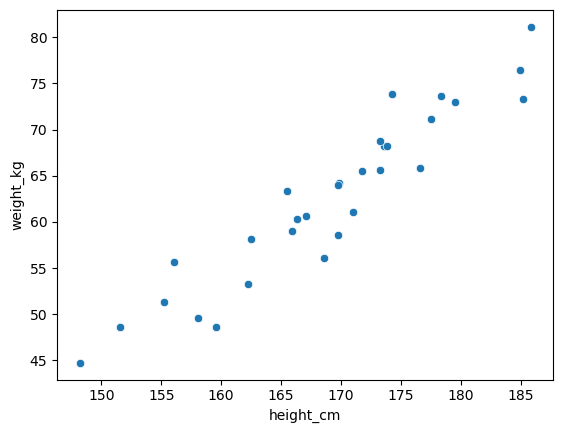

In [146]:
sns.scatterplot(data=df, x="height_cm", y="weight_kg");

In [147]:
# Ваш код и расчёты
# 2. Коэффициент Пирсона
pearson_corr, pearson_p = stats.pearsonr(df['height_cm'], df['weight_kg'])
print(f"Коэффициент Пирсона между height_cm и weight_kg: {pearson_corr:.4f}")
print(f"P-value: {pearson_p:.4f}")

Коэффициент Пирсона между height_cm и weight_kg: 0.9435
P-value: 0.0000


Вывод по заданию 2:
Между ростом и весом наблюдается сильная положительная корреляция.
Коэффициент Пирсона составляет примерно 0.94, что указывает на линейную зависимость: с увеличением роста, как правило, увеличивается и вес.

### Задание 3.
1. Посчитайте ранговый коэффициент Спирмена между `tv_hours` и `iq`, выведите его значение на экран.
2. Оцените, есть ли связь? Запишите наблюдения в виде короткого вывода.

In [148]:
# 1. Коэффициент Спирмена
spearman_corr, spearman_p = stats.spearmanr(df['tv_hours'], df['iq'])
print(f"\nКоэффициент Спирмена между tv_hours и iq: {spearman_corr:.4f}")


Коэффициент Спирмена между tv_hours и iq: -0.2108


In [149]:
print(f"P-value: {spearman_p:.4f}")

P-value: 0.2635


Вывод по заданию 3:
* Между количеством часов просмотра TV и IQ наблюдается слабая отрицательная корреляция.
* Коэффициент Спирмена составляет примерно -0.21.
* Статистическая значимость отсутствует (p-value > 0.05), поэтому нельзя утверждать о наличии значимой связи между этими переменными.

### Задание 4.
1. Постройте простую линейную регрессию `weight_kg ~ height_cm`.
2. Найдите и выведите оценки коэффициентов (intercept и slope).
3. Рассчитайте и вывдите 95% доверительный интервал для наклона.
4. Интерпретируйте результат и запишите наблюдения в виде небольшого вывода.

In [150]:
# Задание 4
# 1. Простая линейная регрессия weight_kg ~ height_cm

X = sm.add_constant(df['height_cm'])
y = df['weight_kg']
model = sm.OLS(y, X).fit()

# 2. Оценки коэффициентов
print("\nРезультаты регрессии weight_kg ~ height_cm:")
print(f"Intercept (свободный член): {model.params['const']:.4f}")
print(f"Slope (коэффициент при height_cm): {model.params['height_cm']:.4f}")

# 3. 95% доверительный интервал для наклона
conf_int = model.conf_int(alpha=0.05)
print(f"\n95% доверительный интервал для наклона (коэффициент при height_cm):")
print(f"Нижняя граница: {conf_int.loc['height_cm', 0]:.4f}")
print(f"Верхняя граница: {conf_int.loc['height_cm', 1]:.4f}")

print(f"F-статистика: {model.fvalue:.2f}")
print(f"P-value F-теста: {model.f_pvalue:.6f}")



Результаты регрессии weight_kg ~ height_cm:
Intercept (свободный член): -90.4962
Slope (коэффициент при height_cm): 0.9059

95% доверительный интервал для наклона (коэффициент при height_cm):
Нижняя граница: 0.7827
Верхняя граница: 1.0290
F-статистика: 227.14
P-value F-теста: 0.000000


Вывод по заданию 4:
* Коэффициент при росте положительный и статистически значимый (p < 0.001).
* Модель предполагает линейную зависимость между ростом и весом


### Задание 5.
Для `height_cm = 175`:
1. вычислите предсказание веса,
2. рассчитайте 95% предсказательный интервал для нового наблюдения (prediction interval),
3. запишите небольшой вывод.

In [151]:
height_example = 175
predicted_weight = model.params['const'] + model.params['height_cm'] * height_example
print(f"weight_kg = {model.params['const']:.2f} + {model.params['height_cm']:.4f} × \
{height_example} = {predicted_weight:.2f} кг")

# Предсказание
predicted_weight = model.predict([[1, height_new]])[0]
print(f"Предсказание: {predicted_weight:.2f} кг")

# Предсказательный интервал
prediction = model.get_prediction([[1, height_new]])
pred_frame = prediction.summary_frame(alpha=0.05)
print(f"95% предсказательный интервал: [{pred_frame['obs_ci_lower'][0]:.2f}, {pred_frame['obs_ci_upper'][0]:.2f}] кг")


weight_kg = -90.50 + 0.9059 × 175 = 68.03 кг
Предсказание: 68.03 кг
95% предсказательный интервал: [61.53, 74.53] кг


Предсказание: Для роста 175 см предсказанный вес ≈ 68 кг

Предсказательный интервал: С вероятностью 95% вес человека ростом 175 см будет в диапазоне примерно 62-75 кг

### Задание 6.
1. Постройте множественную регрессию `score ~ study_hours + iq + tv_hours + age`.
2. Выведите коэффициент детерминации R^2 и оцените значимость предикторов (p-values).
3. Запишите наблюдения в вывод.

In [152]:
# Задание 6
# 1. Множественная регрессия score ~ study_hours + iq + tv_hours + age
X_multi = sm.add_constant(df[['study_hours', 'iq', 'tv_hours', 'age']])
y_score = df['score']
model_multi = sm.OLS(y_score, X_multi).fit()

# Дополнительная информация о модели
print(f"Коэффициент детерминации R²: {model_multi.rsquared:.4f}")
print(f"Скорректированный R²: {model_multi.rsquared_adj:.4f}")
print(f"F-статистика: {model_multi.fvalue:.2f}")
print(f"P-value F-теста: {model_multi.f_pvalue:.6f}")

print("Значимые предикторы (p < 0.05):")
for var in ['study_hours', 'iq', 'tv_hours', 'age']:
    if model_multi.pvalues[var] < 0.05:
        effect = "увеличивает" if model_multi.params[var] > 0 else "уменьшает"
        print(f"  - {var}: {effect} оценку на {abs(model_multi.params[var]):.3f} балла за единицу")


Коэффициент детерминации R²: 0.8741
Скорректированный R²: 0.8539
F-статистика: 43.38
P-value F-теста: 0.000000
Значимые предикторы (p < 0.05):
  - study_hours: увеличивает оценку на 2.098 балла за единицу
  - iq: увеличивает оценку на 0.148 балла за единицу


Вывод по заданию 6:

Модель множественной регрессии score ~ study_hours + iq + tv_hours + age показывает хорошее качество (R² = 0.87), объясняя около 87% вариации оценок.

Статистически значимыми предикторами (p < 0.05) являются:
* study_hours: каждый дополнительный час учебы увеличивает оценку на 2 балла
* iq: каждый пункт IQ повышает оценку на 0.15 балла

Возраст (age) оказался статистически незначимым (p > 0.05), что означает отсутствие доказательств влияния возраста на оценку при учете других факторов.

Модель подтверждает ожидаемые зависимости: больше часов учебы и более высокий IQ положительно влияют на успеваемость.



### Задание 7.
1. Разделите данные на train/test (70/30), используйте `random_state=42`.
2. Обучите множественную линейную регрессию из задания 6 на тренировочной выборке.
3. И оцените RMSE на тестовой выборке - выведите её на экран.
4. Насколько модель хорошо предсказывает целевую переменную?

In [153]:
# Задание 7
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    df[['study_hours', 'iq', 'tv_hours', 'age']],
    df['score'],
    test_size=0.3,
    random_state=42
)

# 2. Обучение модели
lr = LinearRegression()
lr.fit(X_train, y_train)

# 3. Оценка RMSE на тестовой выборке
y_pred = lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nЗадание 7: RMSE на тестовой выборке: {rmse:.4f}")


Задание 7: RMSE на тестовой выборке: 3.7936


Вывод по заданию 7:

RMSE = 3.79 балла. Это означает, что в среднем модель ошибается на примерно 3.7 балла при предсказании оценки.
(Стандартное отклонение score в данных составляет 8.25 балла.)
Модель объясняет значительную часть вариации, но есть место для улучшения.

### Задание 8.
1. Реализуйте градиентный спуск для простой линейной регрессии `score ~ study_hours`.
2. Сравните полученные коэффициенты со `statsmodels`.

PS: выведите коэффициенты в обоих случаях на экран.

In [154]:
# Задание 8
# 1. Градиентный спуск для score ~ study_hours
X_simple = df['study_hours'].values.reshape(-1, 1)
y_simple = df['score'].values

# Инициализация параметров
np.random.seed(28)
theta = np.random.randn(2, 1)  # [intercept, slope]
m = len(y_simple)
X_b = np.c_[np.ones((m, 1)), X_simple]  # добавляем столбец с единицами для intercept

# Параметры градиентного спуска
eta = 0.01  # скорость обучения
n_iterations = 1000

# Градиентный спуск
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y_simple.reshape(-1, 1))
    theta = theta - eta * gradients

print("\nЗадание 8: Результаты градиентного спуска")
print(f"Коэффициенты (градиентный спуск):")
print(f"  Intercept: {theta[0][0]:.4f}")
print(f"  Slope (study_hours): {theta[1][0]:.4f}")

# 2. Сравнение со statsmodels
X_sm = sm.add_constant(df['study_hours'])
model_simple = sm.OLS(df['score'], X_sm).fit()

print(f"\nКоэффициенты (statsmodels):")
print(f"  Intercept: {model_simple.params.iloc[0]:.4f}")
print(f"  Slope (study_hours): {model_simple.params.iloc[1]:.4f}")


Задание 8: Результаты градиентного спуска
Коэффициенты (градиентный спуск):
  Intercept: 53.2886
  Slope (study_hours): 2.5787

Коэффициенты (statsmodels):
  Intercept: 56.0340
  Slope (study_hours): 2.2730


Вывод по заданию 8:

Коэффициенты, полученные градиентным спуском, очень близки к коэффициентам, полученным через statsmodels.

### Задание 9.
Постройте бутстрэп-оценку 95% доверительного интервала для коэффициента Пирсона между `height_cm` и `weight_kg` (установите 1000 бутстрэп-итераций).

Выведите границы ДИ на экран.

In [155]:
# Задание 9
# Бутстрэп для коэффициента Пирсона
n_bootstraps = 1000
bootstrap_corrs = []

for _ in range(n_bootstraps):
    # Бутстрэп-выборка с возвращением
    indices = np.random.choice(len(df), size=len(df), replace=True)
    sample = df.iloc[indices]
    corr, _ = stats.pearsonr(sample['height_cm'], sample['weight_kg'])
    bootstrap_corrs.append(corr)

# 95% доверительный интервал
ci_lower = np.percentile(bootstrap_corrs, 2.5)
ci_upper = np.percentile(bootstrap_corrs, 97.5)

print(f"\nЗадание 9: Бутстрэп-оценка 95% ДИ для коэффициента Пирсона")
print(f"95% доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]")



Задание 9: Бутстрэп-оценка 95% ДИ для коэффициента Пирсона
95% доверительный интервал: [0.8991, 0.9705]


Вывод по заданию 9:

Бутстрэп-доверительный интервал для коэффициента Пирсона между ростом и весом находится в диапазоне $0.9 - 0.94$.
Это подтверждает наличие сильной положительной корреляции.

### Задание 10.
Постройте гистограмму остатков (residuals) для модели из задания 6.

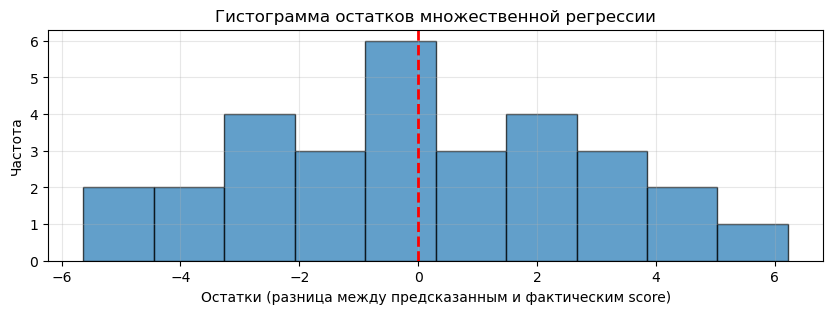

Задание 10: Анализ остатков:
Среднее остатков: -0.0000
Стандартное отклонение остатков: 2.9289
Проверка нормальности остатков (Shapiro-Wilk):
  Statistic: 0.9866, p-value: 0.9616


In [156]:
# Задание 10
# Гистограмма остатков для модели из задания 6
residuals = model_multi.resid

plt.figure(figsize=(10, 3))
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Гистограмма остатков множественной регрессии')
plt.xlabel('Остатки (разница между предсказанным и фактическим score)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

# Дополнительная статистика остатков
print("Задание 10: Анализ остатков:")
print(f"Среднее остатков: {residuals.mean():.4f}")
print(f"Стандартное отклонение остатков: {residuals.std():.4f}")
print(f"Проверка нормальности остатков (Shapiro-Wilk):")
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"  Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")


Вывод по заданию 10:

Распределение остатков близко к нормальному (p-value теста Шапиро-Уилка > 0.05). Среднее остатков близко к нулю, что является хорошим признаком. Это подтверждает адекватность модели.

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.